#About Dataset

Link https://www.kaggle.com/api/v1/datasets/download/moltean/fruits?dataset_version_number=52...

Content

The following fruits, vegetables and nuts and are included:
Apples (different varieties: Crimson Snow, Golden, Golden-Red, Granny Smith, Pink Lady, Red, Red Delicious), Apricot, Avocado, Avocado ripe, Banana (Yellow, Red, Lady Finger), Beans, Beetroot Red, Blackberry, Blueberry, Cabbage, Caju seed, Cactus fruit, Cantaloupe (2 varieties), Carambula, Carrot, Cauliflower, Cherimoya, Cherry (different varieties, Rainier), Cherry Wax (Yellow, Red, Black), Chestnut, Clementine, Cocos, Corn (with husk), Cucumber (ripened, regular), Dates, Eggplant, Fig, Ginger Root, Goosberry, Granadilla, Grape (Blue, Pink, White (different varieties)), Grapefruit (Pink, White), Guava, Hazelnut, Huckleberry, Kiwi, Kaki, Kohlrabi, Kumsquats, Lemon (normal, Meyer), Lime, Lychee, Mandarine, Mango (Green, Red), Mangostan, Maracuja, Melon Piel de Sapo, Mulberry, Nectarine (Regular, Flat), Nut (Forest, Pecan), Onion (Red, White), Orange, Papaya, Passion fruit, Peach (different varieties), Pepino, Pear (different varieties, Abate, Forelle, Kaiser, Monster, Red, Stone, Williams), Pepper (Red, Green, Orange, Yellow), Physalis (normal, with Husk), Pineapple (normal, Mini), Pistachio, Pitahaya Red, Plum (different varieties), Pomegranate, Pomelo Sweetie, Potato (Red, Sweet, White), Quince, Rambutan, Raspberry, Redcurrant, Salak, Strawberry (normal, Wedge), Tamarillo, Tangelo, Tomato (different varieties, Maroon, Cherry Red, Yellow, not ripened, Heart), Walnut, Watermelon, Zucchini (green and dark).

##imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib
from zipfile import ZipFile
import PIL

import tensorflow as tf

##Loading the data

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits' dataset.
Path to dataset files: /kaggle/input/fruits


In [5]:
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/moltean/fruits?dataset_version_number=52"

In [6]:
data_dir = tf.keras.utils.get_file("fruit.zip", origin=dataset_url, cache_dir="/content/")

In [7]:
zf = ZipFile(data_dir)
zf.extractall("/content")

In [8]:
train_dir = pathlib.Path("/content/fruits-360_100x100/fruits-360/Training")
test_dir = pathlib.Path("/content/fruits-360_100x100/fruits-360/Test")

In [9]:
image_count = len(list(train_dir.glob('*/*.jpg')))
image_count

110036

##Exploring the data

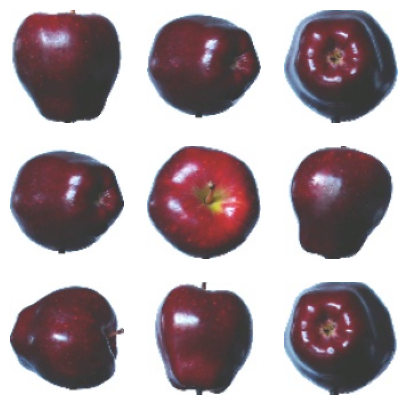

In [10]:
import matplotlib.pyplot as plt
import PIL
import pathlib

# Assuming train_dir is already defined and points to the training data
# For example:
# train_dir = pathlib.Path("/path/to/your/training/data")

fruits = list(train_dir.glob('Apple Red Delicious 1/*.jpg'))

plt.figure(figsize=(5, 5))

# Iterate only up to the number of images available
for i in range(min(len(fruits), 9)):
    plt.subplot(3, 3, i + 1)
    img = PIL.Image.open(str(fruits[i]))
    plt.imshow(img)
    plt.axis('off')

plt.show()

Here is the code from cell `rH4V9E7Vaa0v`:

In [12]:
batch_size = 32
img_height = 100
img_width = 100

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 110036 files belonging to 215 classes.
Using 88029 files for training.
Found 110036 files belonging to 215 classes.
Using 22007 files for validation.
Found 36714 files belonging to 215 classes.


In [14]:
class_names = train_ds.class_names
num_classes = len(class_names)

## Preprocessing/Setting Up Base Model

In [15]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [16]:
data_augmentation = tf.keras.Sequential([

                                        tf.keras.layers.RandomFlip("horizontal"),
                                        tf.keras.layers.RandomRotation(0.2)
                                        ])

In [17]:
preprocess_input = tf.keras.applications.resnet.preprocess_input # auto feed i/p to resnet model

In [18]:
base_model = tf.keras.applications.resnet.ResNet50(

                                                  input_shape=(img_height, img_width, 3),
                                                  include_top=False,
                                                  weights='imagenet'

)

In [19]:
base_model.trainable = False

In [20]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()  # the way resnet transform the features
prediction_layer = tf.keras.layers.Dense(num_classes)

##Building the Model

In [21]:
inputs = tf.keras.Input(shape=(100, 100, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)


model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [22]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

##Training the Model

In [23]:
model.evaluate(val_ds)

688/688 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.0047 - loss: 7.0436


[7.0397210121154785, 0.0037260870449244976]

In [ ]:
epochs = 10

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

Epoch 1/10
 537/2751 ━━━━━━━━━━━━━━━━━━━━ 1:29 41ms/step - accuracy: 0.5267 - loss: 2.5059

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 10))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc='upper left')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
np.argmin(val_loss)